<a href="https://colab.research.google.com/github/Aasthahcs05/Case-study/blob/main/Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

from google.colab import files
files.upload()   # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aastha685","key":"e782fc8d608c579122378c32856e1891"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 243MB/s]



In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [5]:
img_size = 224
batch_size = 32

train_ds = keras.preprocessing.image_dataset_from_directory(
    "Training",
    image_size=(img_size, img_size),
    batch_size=batch_size
)

test_ds = keras.preprocessing.image_dataset_from_directory(
    "Testing",
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model = keras.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.7973 - loss: 0.5351 - val_accuracy: 0.8444 - val_loss: 0.5615
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8727 - loss: 0.3340 - val_accuracy: 0.8575 - val_loss: 0.5392
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8971 - loss: 0.2814 - val_accuracy: 0.8706 - val_loss: 0.5203
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9068 - loss: 0.2432 - val_accuracy: 0.8831 - val_loss: 0.4654
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9209 - loss: 0.2099 - val_accuracy: 0.8813 - val_loss: 0.4837
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9341 - loss: 0.1804 - val_accuracy: 0.8875 - val_loss: 0.5287
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9323 - loss: 0.1805 - val_accuracy: 0.8850 - val_loss: 0.4649
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9409 - loss: 0.1579 - val_ac

In [11]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8981 - loss: 0.5902
Test Accuracy: 0.8981249928474426


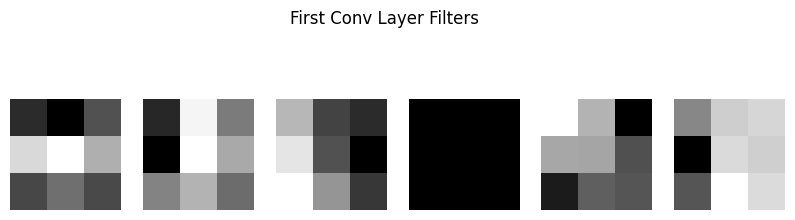

In [23]:

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break


for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_layer = layer
        break

# Get filters
filters = first_conv_layer.get_weights()[0]

# Normalize filters
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Plot filters
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(filters[:, :, 0, i], cmap='gray')
    plt.axis('off')

plt.suptitle("First Conv Layer Filters")
plt.show()

In [24]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [25]:
img_path = "/content/Testing/glioma/Te-gl_100.jpg"

img = keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array/255.0, axis=0)

In [26]:
# Last conv layer in MobileNetV2
last_conv_layer_name = "Conv_1"

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

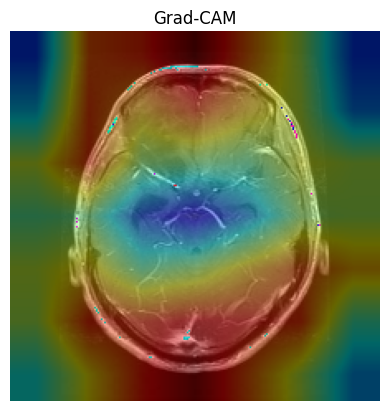

In [27]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [28]:
pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Class: glioma
